In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

### Data Collection and Analysis
### PIMA Diabetes Dataset

In [2]:
# loading the diabetes dataset to a pandas DataFrame
df = pd.read_csv('diabetes.csv') 

| Feature                  | Meaning                   |
| ------------------------ | ------------------------- |
| Pregnancies              | Pregnancy count           |
| Glucose                  | Blood sugar level         |
| BloodPressure            | Blood pressure            |
| SkinThickness            | Body fat indicator        |
| Insulin                  | Hormone controlling sugar |
| BMI                      | Body weight condition     |
| DiabetesPedigreeFunction | Genetic risk              |
| Age                      | Age factor                |
| Outcome                  | Diabetes (Yes/No)         |

In [3]:
# printing the sample 10 rows of the dataset
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
467,0,97,64,36,100,36.8,0.600,25,0
425,4,184,78,39,277,37.0,0.264,31,1
750,4,136,70,0,0,31.2,1.182,22,1
591,2,112,78,50,140,39.4,0.175,24,0
699,4,118,70,0,0,44.5,0.904,26,0
639,1,100,74,12,46,19.5,0.149,28,0
615,3,106,72,0,0,25.8,0.207,27,0
674,8,91,82,0,0,35.6,0.587,68,0
678,3,121,52,0,0,36.0,0.127,25,1
93,4,134,72,0,0,23.8,0.277,60,1


In [4]:
# number of rows and Columns in this dataset
df.shape

(768, 9)

In [5]:
# getting the statistical measures of the data
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in cols:
    print(col, (df[col] == 0).sum())

Pregnancies 111
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Age 0


In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Pregnancies column

In [11]:
df['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

<Axes: xlabel='Pregnancies', ylabel='Density'>

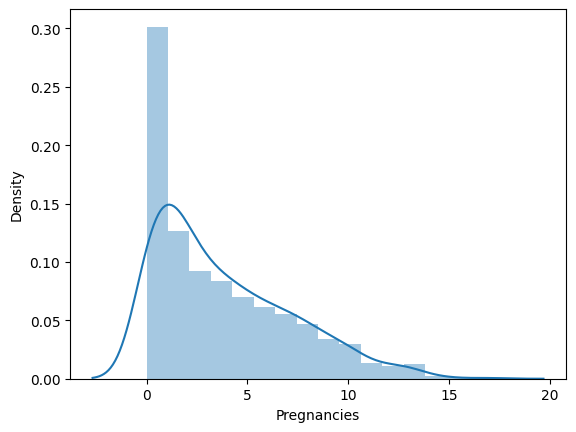

In [12]:
sns.distplot(df['Pregnancies'])

<Axes: ylabel='Pregnancies'>

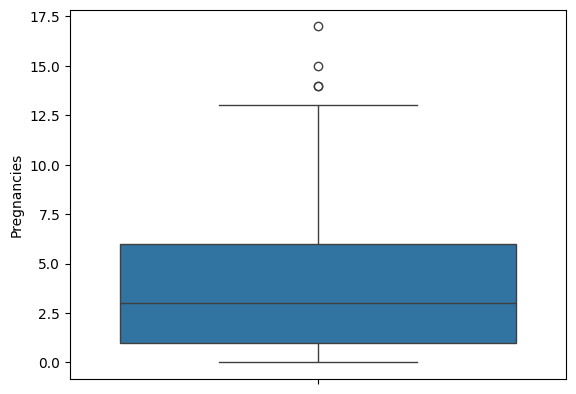

In [13]:
sns.boxplot(df['Pregnancies'])

In [14]:
# Step 1: Keep 0 values (do NOT replace them)
# Because 0 pregnancies is valid data

upper_limit = df['Pregnancies'].quantile(0.99)
lower_limit = df['Pregnancies'].quantile(0.01)
median_value = df['Pregnancies'].median()

# Replace only outliers with median
df.loc[df['Pregnancies'] > upper_limit, 'Pregnancies'] = median_value
df.loc[df['Pregnancies'] < lower_limit, 'Pregnancies'] = median_value

# Convert to integer
df['Pregnancies'] = df['Pregnancies'].round().astype(int)

# Step 2: Save cleaned version into new_df
new_df = df.copy()

In [15]:
new_df['Pregnancies'].describe()

count    768.000000
mean       3.782552
std        3.270644
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       13.000000
Name: Pregnancies, dtype: float64

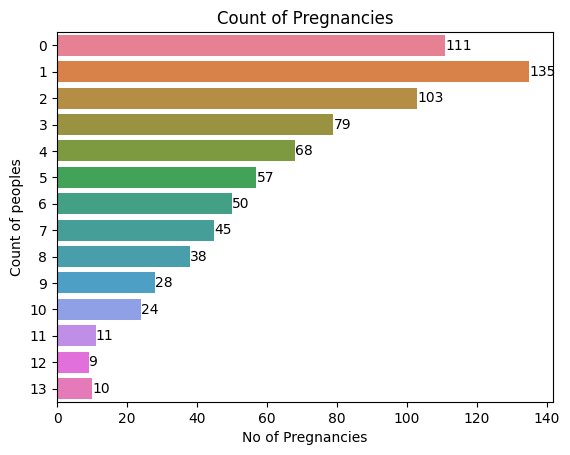

In [16]:
ax = sns.countplot(y='Pregnancies', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Count of Pregnancies")
plt.xlabel("No of Pregnancies")
plt.ylabel("Count of peoples")
plt.show()

In [17]:
df['Pregnancies'].describe()

count    768.000000
mean       3.782552
std        3.270644
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       13.000000
Name: Pregnancies, dtype: float64

In [18]:
new_df['Pregnancies'].describe()

count    768.000000
mean       3.782552
std        3.270644
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       13.000000
Name: Pregnancies, dtype: float64

<Axes: ylabel='Pregnancies'>

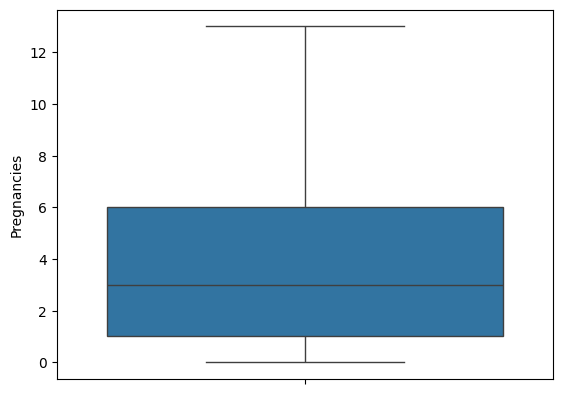

In [19]:
sns.boxplot(new_df['Pregnancies'])

<Axes: xlabel='Pregnancies', ylabel='Density'>

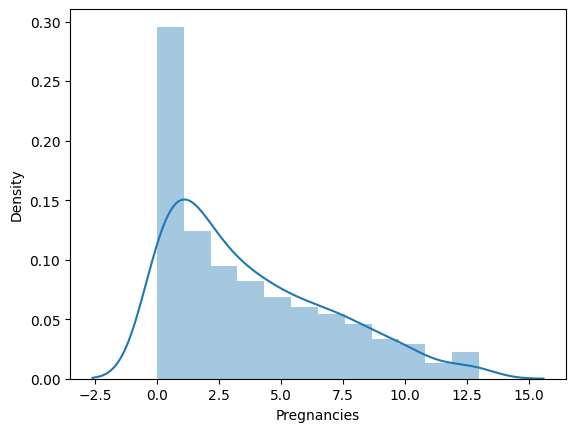

In [20]:
sns.distplot(new_df['Pregnancies'])

In [21]:
new_df['Pregnancies'] = np.log1p(new_df['Pregnancies'])

<Axes: xlabel='Pregnancies', ylabel='Density'>

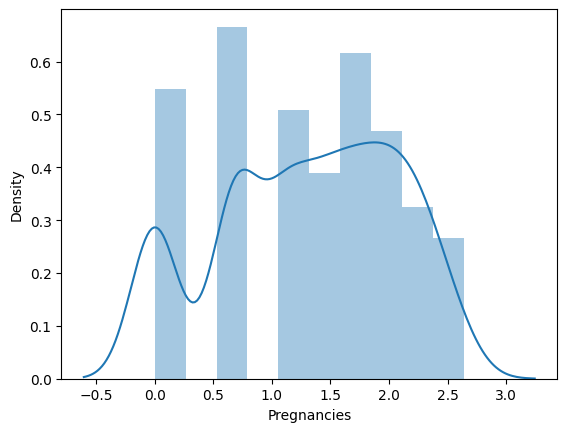

In [22]:
sns.distplot(new_df['Pregnancies'])

<Axes: ylabel='Pregnancies'>

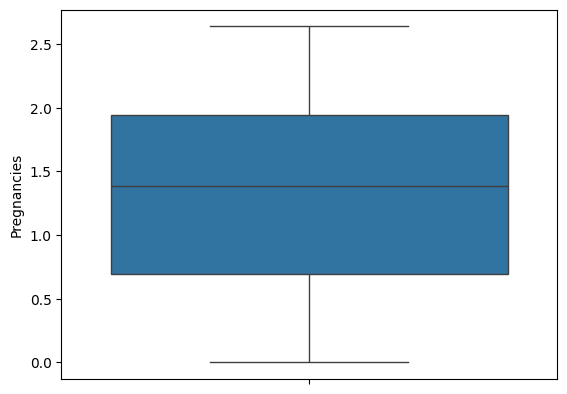

In [23]:
sns.boxplot(new_df['Pregnancies'])

# Glucose column

In [24]:
df['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

<Axes: xlabel='Glucose', ylabel='Density'>

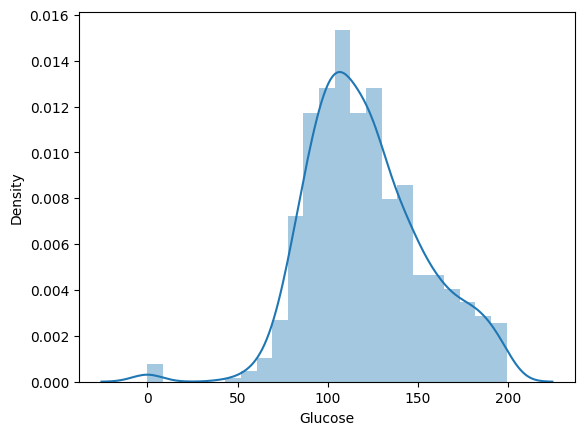

In [25]:
sns.distplot(df['Glucose'])

<Axes: ylabel='Glucose'>

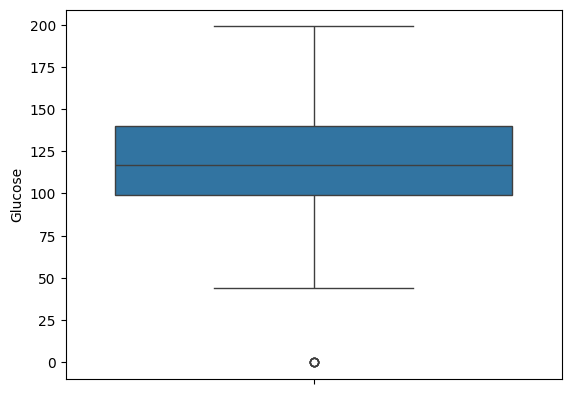

In [26]:
sns.boxplot(df['Glucose'])

In [27]:
df[df['Glucose'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [28]:
# 1. Replace 0 with NaN so they are ignored in the mean calculation
df['Glucose'] = df['Glucose'].replace(0, np.nan)

# 2. Fill the NaNs with the mean of the non-zero values
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())

In [29]:
new_df['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [30]:
df['Glucose'].describe()

count    768.000000
mean     121.686763
std       30.435949
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

<Axes: xlabel='Glucose', ylabel='Density'>

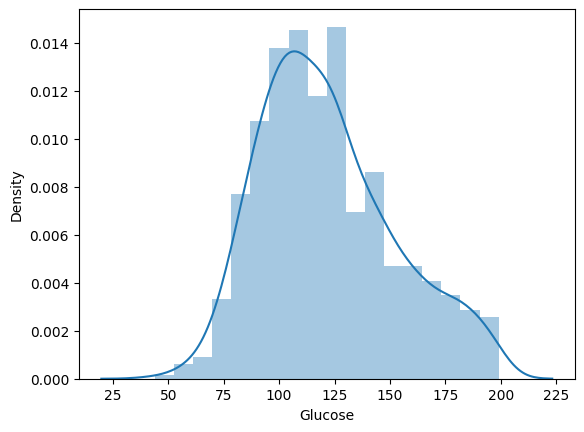

In [31]:
sns.distplot(df['Glucose'])

<Axes: ylabel='Glucose'>

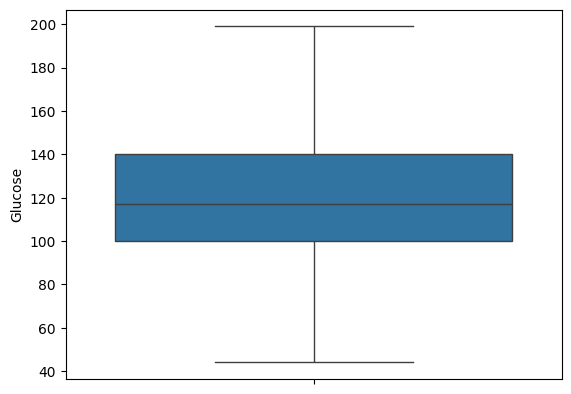

In [32]:
sns.boxplot(df['Glucose'])

In [33]:
new_df['Glucose_Level'] = df['Glucose'].apply(
    lambda g: "Low (Dangerous)" if g < 70 else
              "Normal (Healthy)" if g <= 99 else
              "Pre-diabetes (Risk zone)" if g <= 125 else
              "High (Diabetes)"
)
new_df.drop(columns=['Glucose'], inplace=True)

In [34]:
new_df.sample(5)

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level
443,2.197225,70,0,0,30.5,0.955,33,1,Pre-diabetes (Risk zone)
317,1.386294,74,0,0,30.5,0.345,29,1,High (Diabetes)
710,1.386294,64,13,387,31.2,0.295,24,0,High (Diabetes)
643,1.609438,0,0,0,28.0,0.610,31,0,Normal (Healthy)
4,0.000000,40,35,168,43.1,2.288,33,1,High (Diabetes)


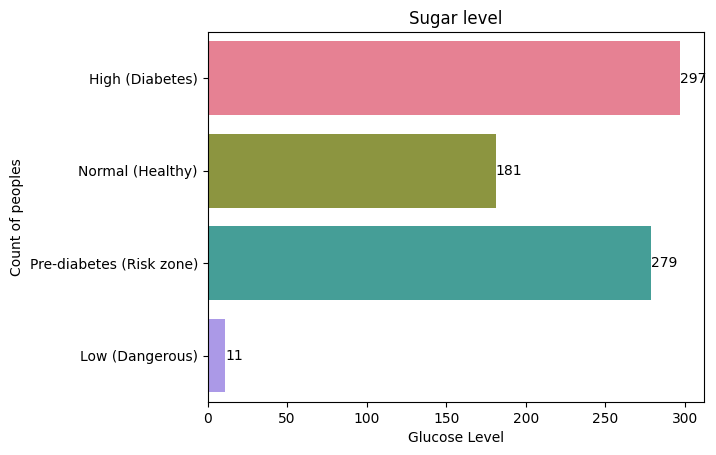

In [35]:
ax = sns.countplot(y='Glucose_Level', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Sugar level")
plt.xlabel("Glucose Level")
plt.ylabel("Count of peoples")
plt.show()

# BloodPressure column

In [36]:
df['BloodPressure'].describe()

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

<Axes: xlabel='BloodPressure', ylabel='Density'>

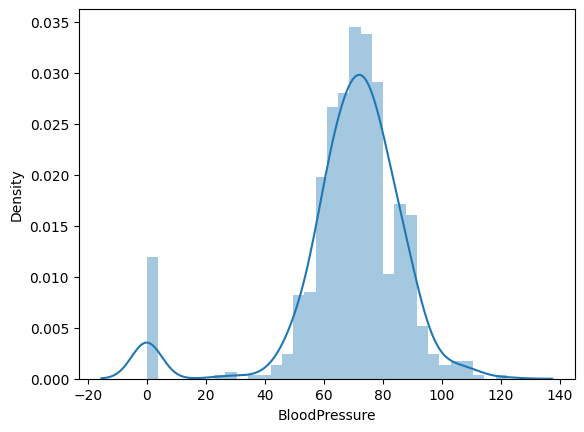

In [37]:
sns.distplot(df['BloodPressure'])

<Axes: ylabel='BloodPressure'>

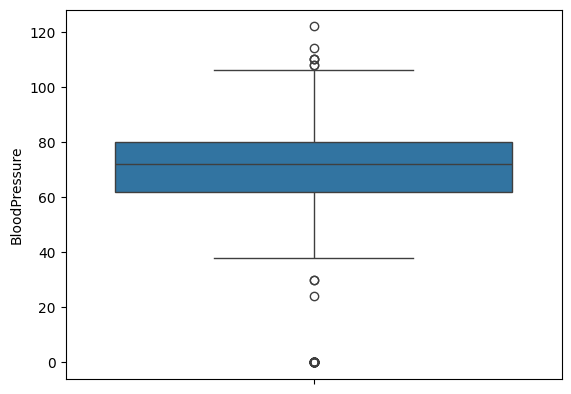

In [38]:
sns.boxplot(df['BloodPressure'])

In [39]:
df[df['BloodPressure'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115.0,0,0,0,35.3,0.134,29,0
15,7,100.0,0,0,0,30.0,0.484,32,1
49,7,105.0,0,0,0,0.0,0.305,24,0
60,2,84.0,0,0,0,0.0,0.304,21,0
78,0,131.0,0,0,0,43.2,0.270,26,1
81,2,74.0,0,0,0,0.0,0.102,22,0
172,2,87.0,0,23,0,28.9,0.773,25,0
193,11,135.0,0,0,0,52.3,0.578,40,1
222,7,119.0,0,0,0,25.2,0.209,37,0
261,3,141.0,0,0,0,30.0,0.761,27,1


In [40]:
# 1. Replace 0 with NaN so they are ignored in the mean calculation
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)

# 2. Fill the NaNs with the mean of the non-zero values
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())

upper_limit = df['BloodPressure'].quantile(0.99)
lower_limit = df['BloodPressure'].quantile(0.01)
median_value = df['BloodPressure'].median()

df.loc[df['BloodPressure'] > upper_limit, 'BloodPressure'] = median_value
df.loc[df['BloodPressure'] < lower_limit, 'BloodPressure'] = median_value

# Step 2: Save cleaned version into new_df
new_df['BloodPressure'] = df['BloodPressure']

In [41]:
new_df

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level
0,1.945910,72.000000,35,0,33.6,0.627,50,1,High (Diabetes)
1,0.693147,66.000000,29,0,26.6,0.351,31,0,Normal (Healthy)
2,2.197225,64.000000,0,0,23.3,0.672,32,1,High (Diabetes)
3,0.693147,66.000000,23,94,28.1,0.167,21,0,Normal (Healthy)
4,0.000000,72.202592,35,168,43.1,2.288,33,1,High (Diabetes)
...,...,...,...,...,...,...,...,...,...
763,2.397895,76.000000,48,180,32.9,0.171,63,0,Pre-diabetes (Risk zone)
764,1.098612,70.000000,27,0,36.8,0.340,27,0,Pre-diabetes (Risk zone)
765,1.791759,72.000000,23,112,26.2,0.245,30,0,Pre-diabetes (Risk zone)
766,0.693147,60.000000,0,0,30.1,0.349,47,1,High (Diabetes)


In [42]:
df['BloodPressure'].describe()

count    768.000000
mean      72.304183
std       11.016414
min       44.000000
25%       64.000000
50%       72.202592
75%       80.000000
max      106.000000
Name: BloodPressure, dtype: float64

In [43]:
new_df['BloodPressure'].describe()

count    768.000000
mean      72.304183
std       11.016414
min       44.000000
25%       64.000000
50%       72.202592
75%       80.000000
max      106.000000
Name: BloodPressure, dtype: float64

<Axes: xlabel='BloodPressure', ylabel='Density'>

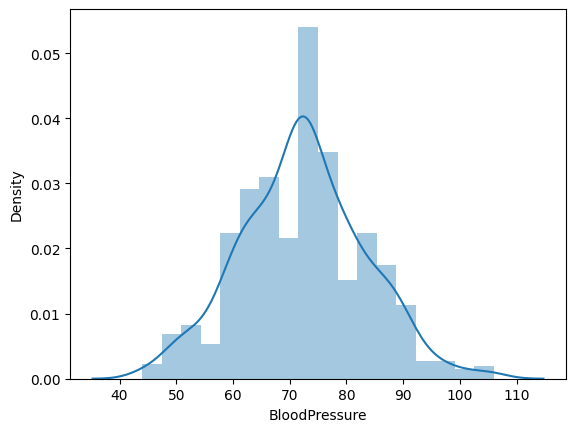

In [44]:
sns.distplot(df['BloodPressure'])

<Axes: ylabel='BloodPressure'>

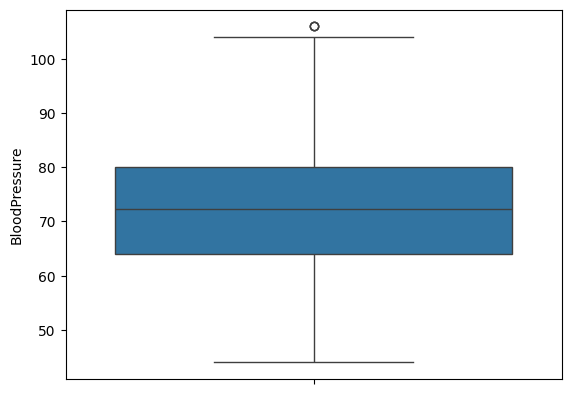

In [45]:
sns.boxplot(df['BloodPressure'])

In [46]:
new_df['BP_Level'] = df['BloodPressure'].apply(
    lambda bp: "Low" if bp < 60 else
               "Normal" if bp <= 80 else
               "High"
)
new_df.drop(columns=['BloodPressure'], inplace=True)

In [47]:
new_df.sample(5)

,Pregnancies,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level,BP_Level
479,1.609438,31,0,28.0,0.419,63,0,High (Diabetes),High
84,1.791759,0,0,48.8,0.227,37,1,High (Diabetes),Normal
739,0.693147,0,0,39.5,0.293,42,1,Pre-diabetes (Risk zone),Normal
521,1.386294,33,130,33.2,0.305,26,0,Pre-diabetes (Risk zone),Normal
709,1.098612,32,160,38.0,0.674,23,1,Normal (Healthy),Normal


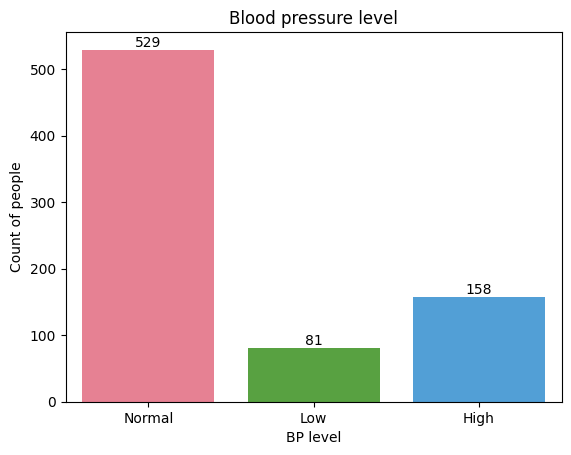

In [48]:
ax = sns.countplot(x='BP_Level', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Blood pressure level")
plt.xlabel("BP level")
plt.ylabel("Count of people")
plt.show()

# SkinThickness column

In [49]:
df['SkinThickness'].describe()

count    768.000000
mean      20.536458
std       15.952218
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

<Axes: xlabel='SkinThickness', ylabel='Density'>

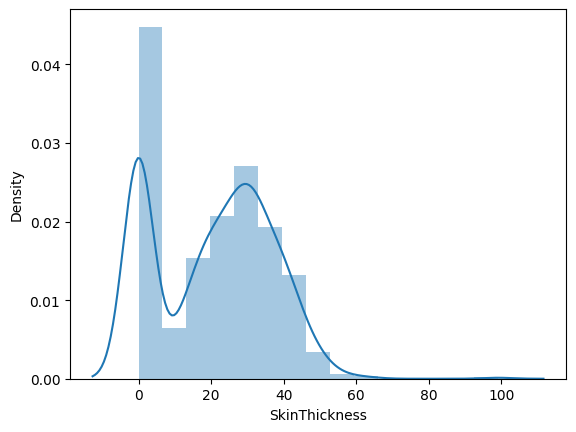

In [50]:
sns.distplot(df['SkinThickness'])

<Axes: ylabel='SkinThickness'>

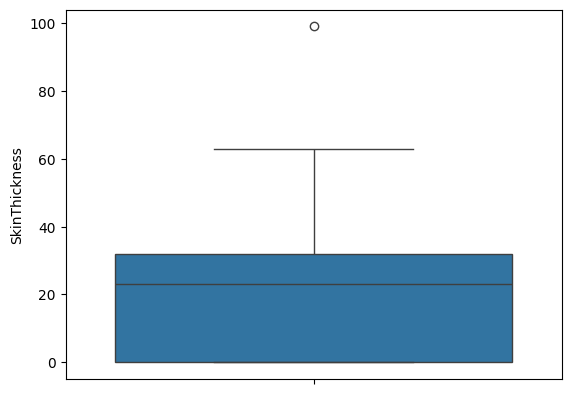

In [51]:
sns.boxplot(df['SkinThickness'])

In [52]:
# Replace 0 with NaN first (0 means missing in this dataset)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)

# Fill missing values with median
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())

<Axes: xlabel='SkinThickness', ylabel='Count'>

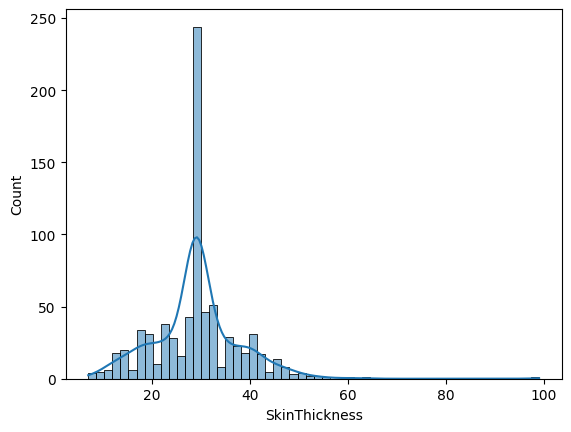

In [53]:
sns.histplot(df['SkinThickness'], kde=True)

<Axes: ylabel='SkinThickness'>

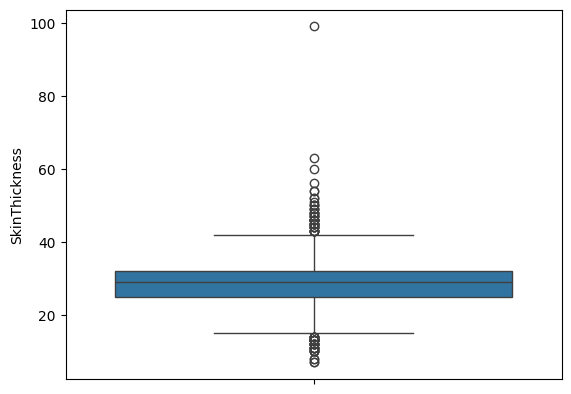

In [54]:
sns.boxplot(y=df['SkinThickness'])

In [55]:
df['SkinThickness'].describe()

count    768.000000
mean      29.108073
std        8.791221
min        7.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

In [56]:
# Step 3: Calculate IQR
Q1 = df['SkinThickness'].quantile(0.25)
Q3 = df['SkinThickness'].quantile(0.75)
IQR = Q3 - Q1

# Step 4: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 5: Cap outliers
df['SkinThickness'] = df['SkinThickness'].clip(lower_bound, upper_bound)

# Step 6: Convert to integer
df['SkinThickness'] = df['SkinThickness'].round().astype(int)

# Step 2: Save cleaned version into new_df
new_df['SkinThickness'] = df['SkinThickness']

In [57]:
df['SkinThickness'].describe()

count    768.000000
mean      28.809896
std        7.435796
min       14.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       42.000000
Name: SkinThickness, dtype: float64

<Axes: xlabel='SkinThickness', ylabel='Density'>

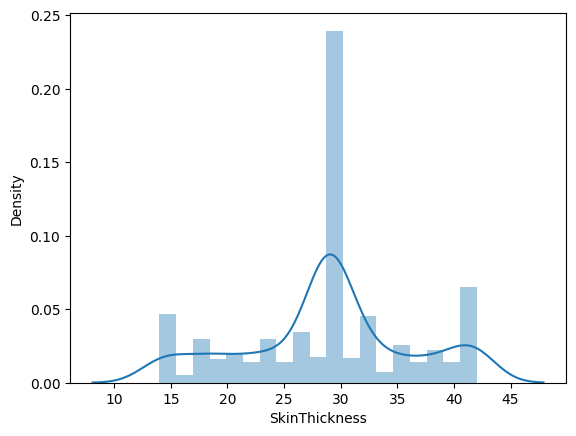

In [58]:
sns.distplot(df['SkinThickness'])

<Axes: ylabel='SkinThickness'>

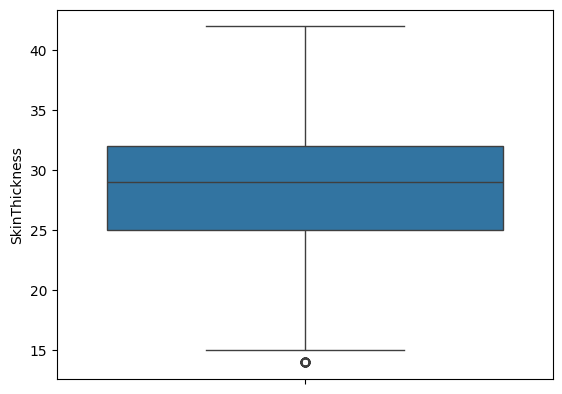

In [59]:
sns.boxplot(y=df['SkinThickness'])

In [60]:
df['SkinThickness'].describe()

count    768.000000
mean      28.809896
std        7.435796
min       14.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       42.000000
Name: SkinThickness, dtype: float64

In [61]:
new_df['Skin_Level'] = pd.cut(
    new_df['SkinThickness'],
    bins=[10, 25, 35, np.inf],
    labels=['Low', 'Normal', 'High']
)
new_df.drop(columns=['SkinThickness'], inplace=True)

In [62]:
new_df.sample(5)

,Pregnancies,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level,BP_Level,Skin_Level
480,1.386294,328,35.5,0.344,35,1,High (Diabetes),Normal,Normal
73,1.609438,270,35.1,0.231,23,0,High (Diabetes),High,Low
258,0.693147,375,25.9,0.655,24,0,High (Diabetes),Low,Low
726,0.693147,180,36.1,0.496,25,0,Pre-diabetes (Risk zone),Normal,Normal
560,1.945910,0,33.8,0.121,54,1,Pre-diabetes (Risk zone),Normal,Normal


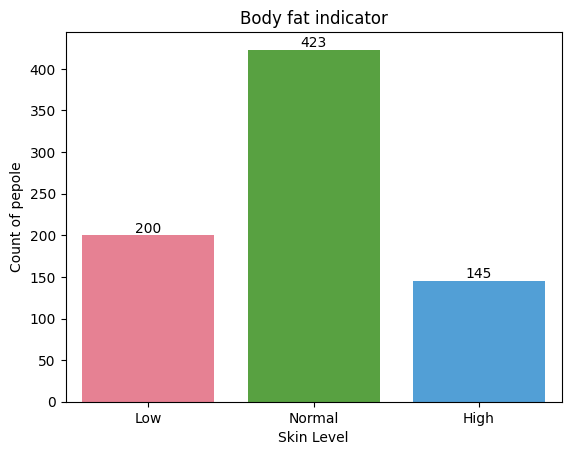

In [63]:
ax = sns.countplot(x='Skin_Level', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Body fat indicator")
plt.xlabel("Skin Level")
plt.ylabel("Count of pepole")
plt.show()

# Insulin column

In [64]:
df['Insulin'].describe()

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

In [65]:
df[df['Insulin'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35,0,33.6,0.627,50,1
1,1,85.0,66.000000,29,0,26.6,0.351,31,0
2,8,183.0,64.000000,29,0,23.3,0.672,32,1
5,5,116.0,74.000000,29,0,25.6,0.201,30,0
7,10,115.0,72.405184,29,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170.0,74.000000,31,0,44.0,0.403,43,1
762,9,89.0,62.000000,29,0,22.5,0.142,33,0
764,2,122.0,70.000000,27,0,36.8,0.340,27,0
766,1,126.0,60.000000,29,0,30.1,0.349,47,1


In [66]:
df.drop(columns=['Insulin'], inplace=True)
new_df.drop(columns=['Insulin'], inplace=True)

In [67]:
new_df.sample(5)

,Pregnancies,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level,BP_Level,Skin_Level
49,2.079442,0.0,0.305,24,0,Pre-diabetes (Risk zone),Normal,Normal
438,0.693147,18.2,0.147,21,0,Normal (Healthy),Normal,Low
385,0.693147,22.3,0.205,24,0,Pre-diabetes (Risk zone),Low,Low
590,2.484907,46.8,0.925,45,1,Pre-diabetes (Risk zone),High,High
429,0.693147,35.0,0.233,43,1,Normal (Healthy),High,Low


# BMI Column

In [68]:
df['BMI'].describe()

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

<Axes: xlabel='BMI', ylabel='Density'>

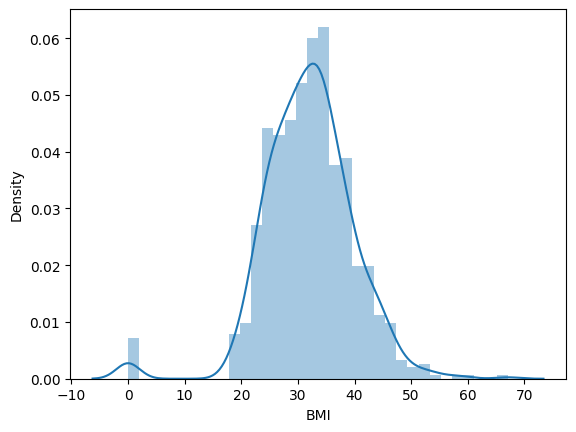

In [69]:
sns.distplot(df['BMI'])

<Axes: ylabel='BMI'>

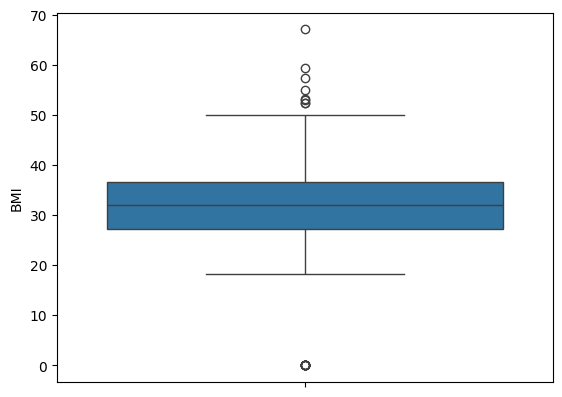

In [70]:
sns.boxplot(df['BMI'])

In [71]:
df[df['BMI'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125.0,96.000000,29,0.0,0.232,54,1
49,7,105.0,72.405184,29,0.0,0.305,24,0
60,2,84.0,72.405184,29,0.0,0.304,21,0
81,2,74.0,72.405184,29,0.0,0.102,22,0
145,0,102.0,75.000000,23,0.0,0.572,21,0
371,0,118.0,64.000000,23,0.0,1.731,21,0
426,0,94.0,72.405184,29,0.0,0.256,25,0
494,3,80.0,72.405184,29,0.0,0.174,22,0
522,6,114.0,72.405184,29,0.0,0.189,26,0
684,5,136.0,82.000000,29,0.0,0.640,69,0


In [72]:
# Replace 0 with NaN first (0 means missing in this dataset)
df['BMI'] = df['BMI'].replace(0, np.nan)

# Fill missing values with median
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

<Axes: xlabel='BMI', ylabel='Density'>

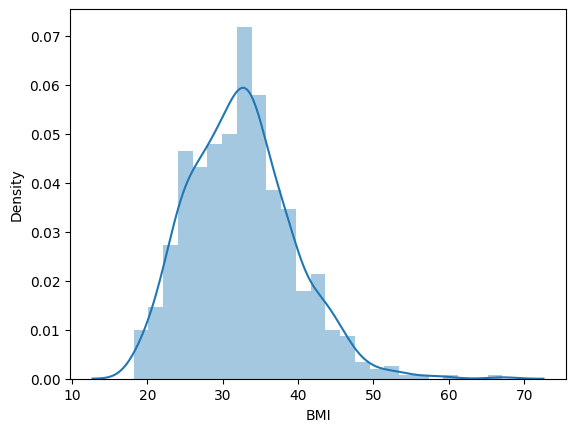

In [73]:
sns.distplot(df['BMI'])

<Axes: ylabel='BMI'>

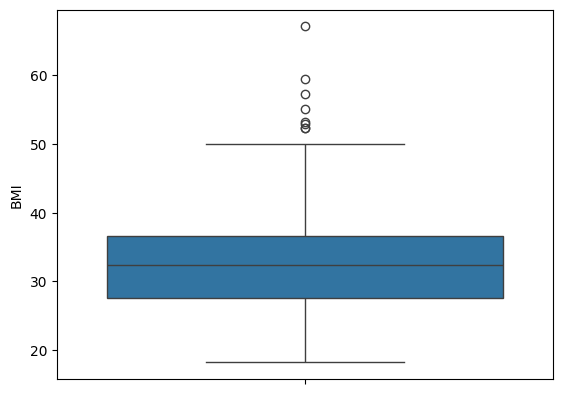

In [74]:
sns.boxplot(df['BMI'])

In [75]:
new_df['BMI_Category'] = pd.cut(df['BMI'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
new_df.drop(columns=['BMI'], inplace=True)

In [76]:
new_df.sample(5)

,Pregnancies,DiabetesPedigreeFunction,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category
346,0.693147,0.654,22,0,High (Diabetes),Low,Low,Overweight
581,1.945910,0.206,27,0,Pre-diabetes (Risk zone),Normal,Normal,Normal
684,1.791759,0.640,69,0,High (Diabetes),High,Normal,Obese
78,0.000000,0.270,26,1,High (Diabetes),Normal,Normal,Obese
633,0.693147,0.115,22,0,High (Diabetes),High,Low,Overweight


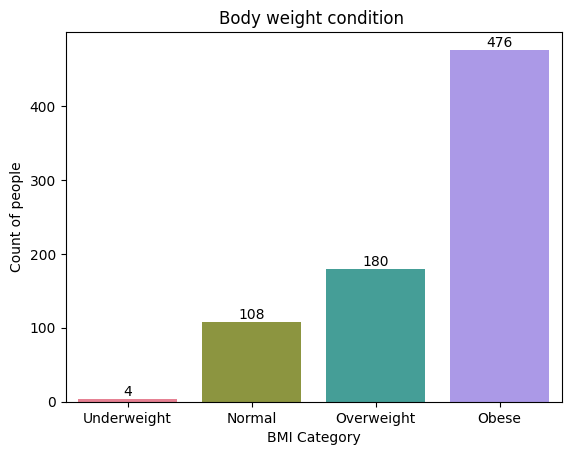

In [77]:
ax = sns.countplot(x='BMI_Category', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Body weight condition ")
plt.xlabel("BMI Category")
plt.ylabel("Count of people")
plt.show()

# Diabetes Pedigree Function Column

In [78]:
df['DiabetesPedigreeFunction'].describe()

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

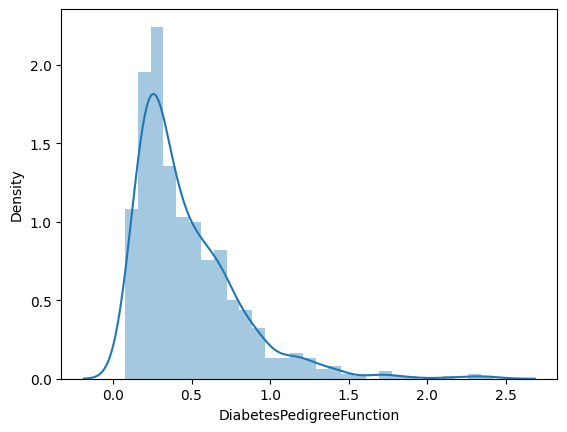

In [79]:
sns.distplot(df['DiabetesPedigreeFunction'])

<Axes: ylabel='DiabetesPedigreeFunction'>

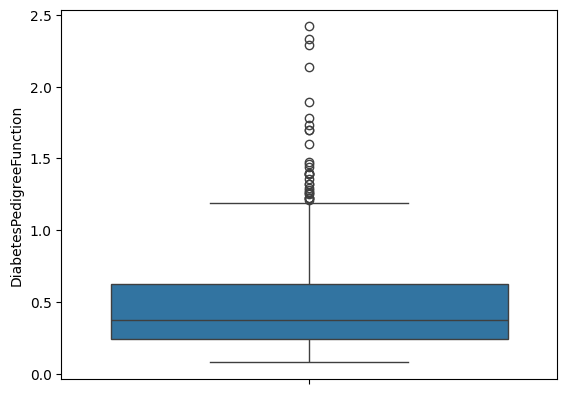

In [80]:
sns.boxplot(df['DiabetesPedigreeFunction'])

In [81]:
df[df['DiabetesPedigreeFunction'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome


In [82]:
df['DiabetesPedigreeFunction'].describe()

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

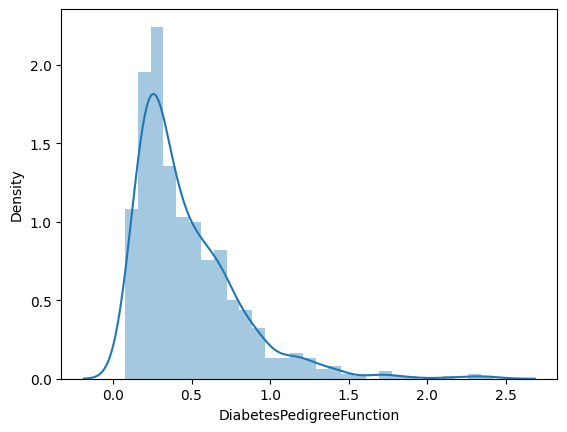

In [83]:
sns.distplot(df['DiabetesPedigreeFunction'])

<Axes: ylabel='DiabetesPedigreeFunction'>

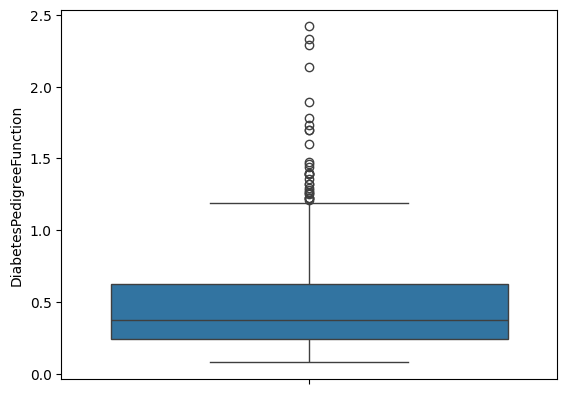

In [84]:
sns.boxplot(df['DiabetesPedigreeFunction'])

In [85]:
new_df['Genetic_Risk'] = pd.cut(
    df['DiabetesPedigreeFunction'],
    bins=[0, 0.3, 0.7, np.inf],
    labels=['Low', 'Medium', 'High']
)
new_df.drop(columns=['DiabetesPedigreeFunction'], inplace=True)

In [86]:
new_df.sample(5)

,Pregnancies,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category,Genetic_Risk
509,2.197225,64,0,Pre-diabetes (Risk zone),Normal,Normal,Normal,Medium
161,2.079442,45,0,Pre-diabetes (Risk zone),Normal,High,Obese,Low
505,2.397895,38,0,Normal (Healthy),High,Normal,Obese,Low
292,1.098612,31,1,High (Diabetes),Normal,High,Obese,High
667,2.397895,40,1,Pre-diabetes (Risk zone),Normal,Normal,Overweight,Low


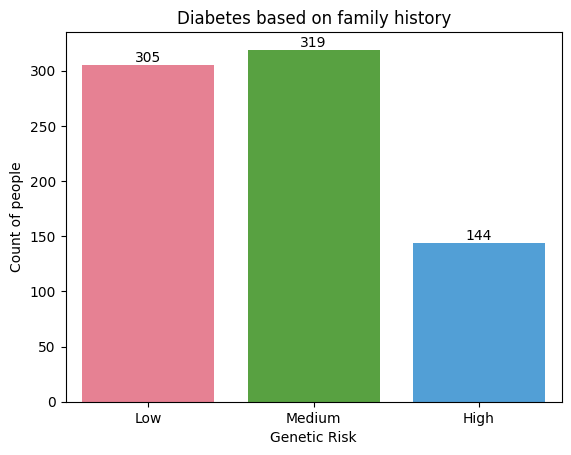

In [87]:
ax = sns.countplot(x='Genetic_Risk', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Diabetes based on family history")
plt.xlabel("Genetic Risk")
plt.ylabel("Count of people")
plt.show()

# Age column

In [88]:
df['Age'].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [89]:
new_df.sample(5)

,Pregnancies,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category,Genetic_Risk
701,1.945910,49,1,Pre-diabetes (Risk zone),Normal,Normal,Overweight,Medium
733,1.098612,22,0,Pre-diabetes (Risk zone),Low,Normal,Overweight,Medium
358,2.564949,48,0,Normal (Healthy),Normal,High,Obese,Medium
732,1.098612,24,1,High (Diabetes),High,High,Obese,Medium
520,1.098612,25,0,Low (Dangerous),Normal,Normal,Normal,Low


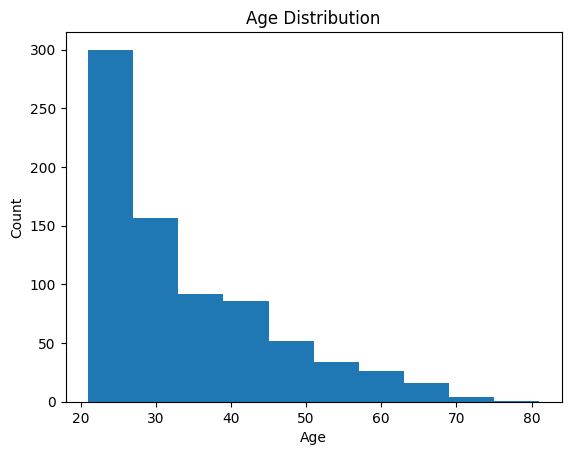

In [90]:
plt.figure()
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [91]:
new_df['Age_Group'] = pd.cut(df['Age'],
    bins=[20, 30, 45, 60, np.inf],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior']
)

In [92]:
new_df.sample(5)

,Pregnancies,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category,Genetic_Risk,Age_Group
242,1.386294,22,1,High (Diabetes),Low,Normal,Overweight,Medium,Young
329,1.945910,37,0,Pre-diabetes (Risk zone),Normal,Normal,Obese,Low,Adult
99,0.693147,31,1,Pre-diabetes (Risk zone),High,High,Obese,Medium,Adult
620,1.098612,28,0,Pre-diabetes (Risk zone),High,High,Obese,Low,Young
403,2.302585,38,0,Normal (Healthy),Normal,Low,Obese,Low,Adult


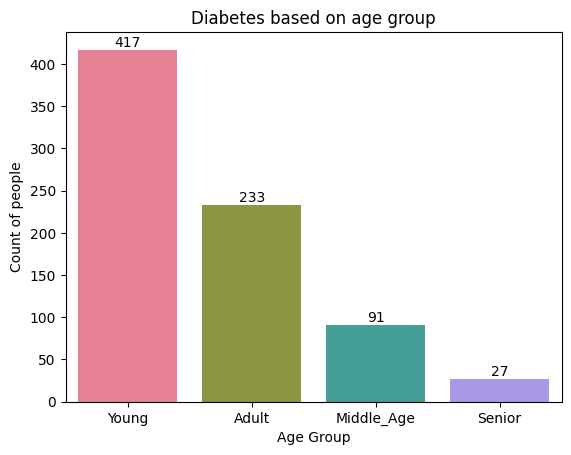

In [93]:
ax = sns.countplot(x='Age_Group', data=new_df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Diabetes based on age group")
plt.xlabel("Age Group")
plt.ylabel("Count of people")
plt.show()

# Outcome column

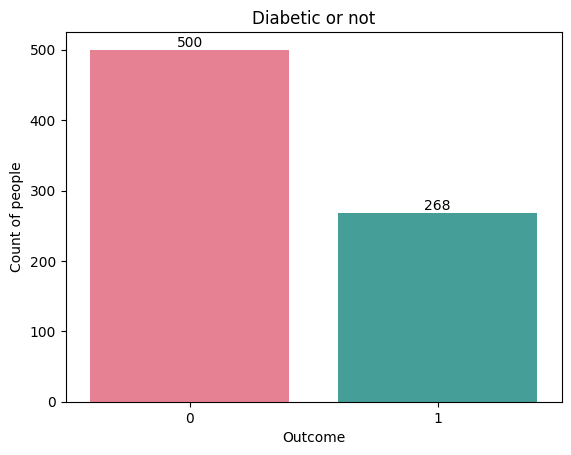

In [94]:
ax = sns.countplot(x='Outcome', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Diabetic or not")
plt.xlabel("Outcome")
plt.ylabel("Count of people")
plt.show()

In [95]:
new_df

,Pregnancies,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category,Genetic_Risk,Age_Group
0,1.945910,50,1,High (Diabetes),Normal,Normal,Obese,Medium,Middle_Age
1,0.693147,31,0,Normal (Healthy),Normal,Normal,Overweight,Medium,Adult
2,2.197225,32,1,High (Diabetes),Normal,Normal,Normal,Medium,Adult
3,0.693147,21,0,Normal (Healthy),Normal,Low,Overweight,Low,Young
4,0.000000,33,1,High (Diabetes),Normal,Normal,Obese,High,Adult
...,...,...,...,...,...,...,...,...,...
763,2.397895,63,0,Pre-diabetes (Risk zone),Normal,High,Obese,Low,Senior
764,1.098612,27,0,Pre-diabetes (Risk zone),Normal,Normal,Obese,Medium,Young
765,1.791759,30,0,Pre-diabetes (Risk zone),Normal,Low,Overweight,Low,Young
766,0.693147,47,1,High (Diabetes),Normal,Normal,Obese,Medium,Middle_Age


In [96]:
for col in new_df.columns:
    print(f"{col}: {new_df[col].count()}")

Pregnancies: 768
Age: 768
Outcome: 768
Glucose_Level: 768
BP_Level: 768
Skin_Level: 768
BMI_Category: 768
Genetic_Risk: 768
Age_Group: 768


In [97]:
for col in df.columns:
    print(f"{col}: {df[col].count()}")

Pregnancies: 768
Glucose: 768
BloodPressure: 768
SkinThickness: 768
BMI: 768
DiabetesPedigreeFunction: 768
Age: 768
Outcome: 768


In [98]:
new_df

,Pregnancies,Age,Outcome,Glucose_Level,BP_Level,Skin_Level,BMI_Category,Genetic_Risk,Age_Group
0,1.945910,50,1,High (Diabetes),Normal,Normal,Obese,Medium,Middle_Age
1,0.693147,31,0,Normal (Healthy),Normal,Normal,Overweight,Medium,Adult
2,2.197225,32,1,High (Diabetes),Normal,Normal,Normal,Medium,Adult
3,0.693147,21,0,Normal (Healthy),Normal,Low,Overweight,Low,Young
4,0.000000,33,1,High (Diabetes),Normal,Normal,Obese,High,Adult
...,...,...,...,...,...,...,...,...,...
763,2.397895,63,0,Pre-diabetes (Risk zone),Normal,High,Obese,Low,Senior
764,1.098612,27,0,Pre-diabetes (Risk zone),Normal,Normal,Obese,Medium,Young
765,1.791759,30,0,Pre-diabetes (Risk zone),Normal,Low,Overweight,Low,Young
766,0.693147,47,1,High (Diabetes),Normal,Normal,Obese,Medium,Middle_Age


In [99]:
x = new_df.drop(columns=["Outcome"])
y = new_df.Outcome

In [100]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [101]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.25, random_state=42)

In [102]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


# GridSearchCV DecisionTreeClassifier

In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

# 1. Identify columns from features 'x'
num_col = x.select_dtypes(include=['number']).columns
cat_col = x.select_dtypes(include=['object', 'category']).columns

# 2. Define sub-pipelines
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encode', OrdinalEncoder(categories=[
        ['Low (Dangerous)', 'Normal (Healthy)', 'Pre-diabetes (Risk zone)', 'High (Diabetes)'],
        ['Low', 'Normal', 'High'],
        ['Low', 'Normal', 'High'],
        ['Underweight', 'Normal', 'Overweight', 'Obese'],
        ['Low', 'Medium', 'High'],
        ['Young', 'Adult', 'Middle_Age', 'Senior']
    ]))
])

# 3. Create the ColumnTransformer
preprocessing = ColumnTransformer([
    ('num', numeric_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

# 4. Define the final Pipeline
dt_pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", DecisionTreeClassifier(random_state=42))
])

# 5. Set up Parameters (using the 'model__' prefix)
param = {
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'model__min_samples_split': [2, 3, 4, 5] 
}

# 6. Run GridSearchCV
GridCV = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param,
    cv=5,
    n_jobs=-1,
    verbose=1
)

GridCV.fit(x_train, y_train)

# Output results
print("Best Parameters:", GridCV.best_params_)
print("Best Score:", GridCV.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 2, 'model__splitter': 'random'}
Best Score: 0.755232383808096


# RandomizedSearchCV DecisionTreeClassifier

In [104]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

# 1. Re-define preprocessing components
num_col = x.select_dtypes(include=['number']).columns
cat_col = x.select_dtypes(include=['object', 'category']).columns

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_col),
    ('cat', OrdinalEncoder(categories=[
        ['Low (Dangerous)', 'Normal (Healthy)', 'Pre-diabetes (Risk zone)', 'High (Diabetes)'],
        ['Low', 'Normal', 'High'],
        ['Low', 'Normal', 'High'],
        ['Underweight', 'Normal', 'Overweight', 'Obese'],
        ['Low', 'Medium', 'High'],
        ['Young', 'Adult', 'Middle_Age', 'Senior']
    ]), cat_col)
])

# 2. Create the Pipeline
# This handles the "string to float" conversion automatically
dt_pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", DecisionTreeClassifier(random_state=42))
])

# 3. Update Parameters
# Added 'model__' prefix and changed min_samples_split to start at 2
param = {
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'model__min_samples_split': [2, 3, 4, 5] 
}

# 4. Run RandomizedSearchCV
RandomCV = RandomizedSearchCV(
    estimator=dt_pipe,
    param_distributions=param,
    n_iter=10, # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

RandomCV.fit(x_train, y_train)

# Output results
print("Best Parameters:", RandomCV.best_params_)
print("Best Score:", RandomCV.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'model__splitter': 'random', 'model__min_samples_split': 2, 'model__max_depth': 4, 'model__criterion': 'entropy'}
Best Score: 0.755232383808096


# GridSearchCV RandomForestClassifier

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline

# 1. Define the Pipeline
# This ensures 'preprocessing' (from your previous cells) handles the strings
rf_pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestClassifier(random_state=42))
])

# 2. Set Parameters
# Use 'model__' prefix and ensure min_samples_split is >= 2
param = {
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'model__min_samples_split': [2, 3, 4] 
}

# 3. Setup GridSearchCV
GridCV1 = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 4. Fit and Print (using consistent variable names)
GridCV1.fit(x_train, y_train)

print("Param Grid:", GridCV1.param_grid)
print("Best Params:", GridCV1.best_params_)
print("Best Score:", GridCV1.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Param Grid: {'model__criterion': ['entropy', 'gini', 'log_loss'], 'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'model__min_samples_split': [2, 3, 4]}
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 4}
Best Score: 0.7620989505247376


# RandomizedSearchCV DecisionTreeClassifier

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline

# 1. Define the Pipeline
# This ensures 'preprocessing' handles the strings like 'High (Diabetes)'
rf_pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestClassifier(random_state=42))
])

# 2. Set Parameters
# Use 'model__' prefix and ensure min_samples_split is >= 2
param = {
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'model__min_samples_split': [2, 3, 4] 
}

# 3. Setup RandomizedSearchCV
RandomCV1 = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 4. Fit and Print (using consistent variable names)
RandomCV1.fit(x_train, y_train)

print("Param Distributions:", RandomCV1.param_distributions)
print("Best Params:", RandomCV1.best_params_)
print("Best Score:", RandomCV1.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Param Distributions: {'model__criterion': ['entropy', 'gini', 'log_loss'], 'model__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'model__min_samples_split': [2, 3, 4]}
Best Params: {'model__min_samples_split': 2, 'model__max_depth': 6, 'model__criterion': 'gini'}
Best Score: 0.753448275862069


# Pipeline

In [107]:
# Imports
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split as tts
from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# This ensures the target column 'Outcome' is not included in preprocessing
num_col = x.select_dtypes(include=['number']).columns
cat_col = x.select_dtypes(include=['object', 'category']).columns

# scaler/encode
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encode', OrdinalEncoder(categories=[
        ['Low (Dangerous)', 'Normal (Healthy)', 'Pre-diabetes (Risk zone)', 'High (Diabetes)'],
        ['Low', 'Normal', 'High'],
        ['Low', 'Normal', 'High'],
        ['Underweight', 'Normal', 'Overweight', 'Obese'],
        ['Low', 'Medium', 'High'],
        ['Young', 'Adult', 'Middle_Age', 'Senior']
    ]))
])

# ColumnTransformer
preprocessing = ColumnTransformer([
    ('num', numeric_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

# Pipelines
pipe_lr = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression())
])

pipe_knn = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

pipe_abc = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", AdaBoostClassifier(n_estimators=100))
])

pipe_gbc = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(n_estimators=100))
])

pipe_cbc = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", CatBoostClassifier(verbose=0))
])

pipe_xgbc = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier())
])

# Model dictionary
models = {
    'Logistic Regression': pipe_lr,
    'KNeighbors Classifier': pipe_knn,
    'AdaBoost Classifier': pipe_abc,
    'Gradient Boosting Classifier': pipe_gbc,
    'CatBoost Classifier': pipe_cbc,
    'XGB Classifier': pipe_xgbc
}

# Training Loop
for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, pred))
    print("-" * 57)

Model: Logistic Regression
Accuracy: 0.7344
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.72      0.78       123
           1       0.60      0.75      0.67        69

    accuracy                           0.73       192
   macro avg       0.72      0.74      0.72       192
weighted avg       0.76      0.73      0.74       192

---------------------------------------------------------
Model: KNeighbors Classifier
Accuracy: 0.6771
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.64      0.72       123
           1       0.54      0.74      0.62        69

    accuracy                           0.68       192
   macro avg       0.68      0.69      0.67       192
weighted avg       0.71      0.68      0.68       192

---------------------------------------------------------
Model: AdaBoost Classifier
Accuracy: 0.7292
Classification Report:
              precision    

In [108]:
# new_df.to_csv('Diabetes_clean.csv', index=False)